<a href="https://colab.research.google.com/github/Zuzed22/Practicando-Python-para-Data-Science-Challenge-Alura-Store/blob/main/ChallengeAluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [11]:
tienda.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

#1. Análisis de facturación



In [13]:
# Facturación en base a una unidad por venta
tienda["facturacion"] = tienda["Precio"]

# Total facturado por tienda
facturacion_total = tienda["facturacion"].sum()


In [15]:
# Calculamos la facturación total para cada tienda
facturacion_total = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

# Lo convertimos en un DataFrame para visualizar mejor
facturacion_df = pd.DataFrame(list(facturacion_total.items()), columns=["Tienda", "Facturación Total"])
facturacion_df.sort_values(by="Facturación Total", ascending=False, inplace=True)

# Mostramos la tabla
facturacion_df


,Tienda,Facturación Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


<ipython-input-16-54c474a9fcdc>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tienda", y="Facturación Total", data=facturacion_df, palette="viridis")


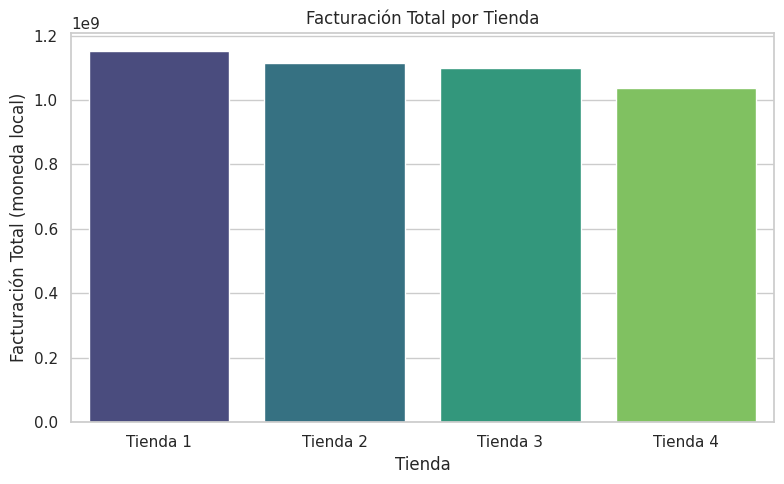

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="Tienda", y="Facturación Total", data=facturacion_df, palette="viridis")
plt.title("Facturación Total por Tienda")
plt.ylabel("Facturación Total (moneda local)")
plt.xlabel("Tienda")
plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [17]:
# Conteo de categorías en cada tienda
categorias_t1 = tienda["Categoría del Producto"].value_counts()
categorias_t2 = tienda2["Categoría del Producto"].value_counts()
categorias_t3 = tienda3["Categoría del Producto"].value_counts()
categorias_t4 = tienda4["Categoría del Producto"].value_counts()

# Mostramos el top 5 categorías más vendidas por tienda
print("Tienda 1 - Top 5 categorías:\n", categorias_t1.head(), "\n")
print("Tienda 2 - Top 5 categorías:\n", categorias_t2.head(), "\n")
print("Tienda 3 - Top 5 categorías:\n", categorias_t3.head(), "\n")
print("Tienda 4 - Top 5 categorías:\n", categorias_t4.head(), "\n")

Tienda 1 - Top 5 categorías:
 Categoría del Producto
Muebles                 465
Electrónicos            448
Juguetes                324
Electrodomésticos       312
Deportes y diversión    284
Name: count, dtype: int64 

Tienda 2 - Top 5 categorías:
 Categoría del Producto
Muebles                 442
Electrónicos            422
Juguetes                313
Electrodomésticos       305
Deportes y diversión    275
Name: count, dtype: int64 

Tienda 3 - Top 5 categorías:
 Categoría del Producto
Muebles                 499
Electrónicos            451
Juguetes                315
Electrodomésticos       278
Deportes y diversión    277
Name: count, dtype: int64 

Tienda 4 - Top 5 categorías:
 Categoría del Producto
Muebles                 480
Electrónicos            451
Juguetes                338
Deportes y diversión    277
Electrodomésticos       254
Name: count, dtype: int64 



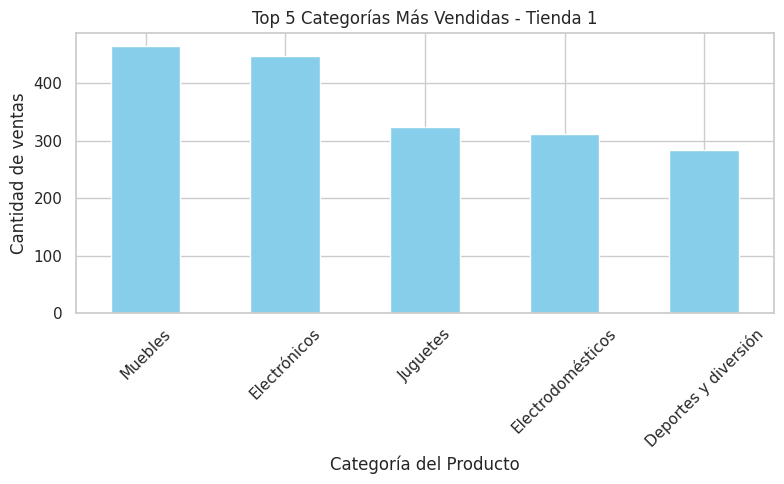

In [18]:
# Ejemplo para Tienda 1
plt.figure(figsize=(8,5))
categorias_t1.head(5).plot(kind='bar', color='skyblue')
plt.title("Top 5 Categorías Más Vendidas - Tienda 1")
plt.ylabel("Cantidad de ventas")
plt.xlabel("Categoría del Producto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [19]:
# Aseguramos que la columna 'Calificación' sea numérica (por si acaso)
tienda["Calificación"] = pd.to_numeric(tienda["Calificación"], errors='coerce')
tienda2["Calificación"] = pd.to_numeric(tienda2["Calificación"], errors='coerce')
tienda3["Calificación"] = pd.to_numeric(tienda3["Calificación"], errors='coerce')
tienda4["Calificación"] = pd.to_numeric(tienda4["Calificación"], errors='coerce')

# Calculamos la calificación promedio de cada tienda
evaluacion_promedio = {
    "Tienda 1": tienda["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean()
}

# Creamos un DataFrame para visualización
evaluacion_df = pd.DataFrame(list(evaluacion_promedio.items()), columns=["Tienda", "Evaluación Promedio"])
evaluacion_df.sort_values(by="Evaluación Promedio", ascending=False, inplace=True)

# Mostramos resultados
evaluacion_df


,Tienda,Evaluación Promedio
2,Tienda 3,4.048326
1,Tienda 2,4.037304
3,Tienda 4,3.995759
0,Tienda 1,3.976685


<ipython-input-29-7faf841e4922>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(evaluacion_df, x='Evaluación Promedio', y='Tienda', inner='stick', palette='Dark2')


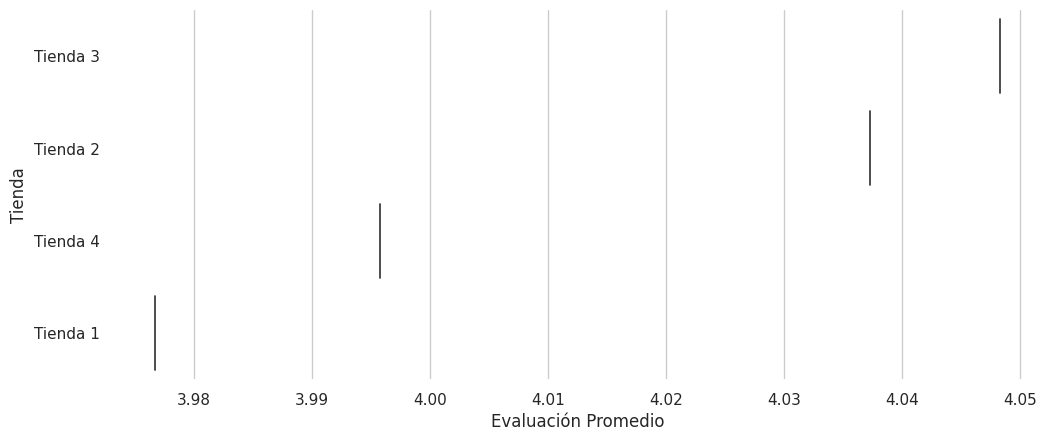

In [29]:
# @title Tienda vs Evaluación Promedio

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(evaluacion_df['Tienda'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(evaluacion_df, x='Evaluación Promedio', y='Tienda', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

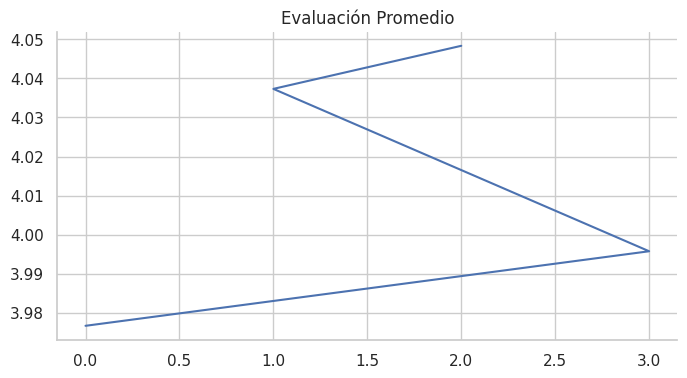

In [21]:
# @title Evaluación Promedio

from matplotlib import pyplot as plt
evaluacion_df['Evaluación Promedio'].plot(kind='line', figsize=(8, 4), title='Evaluación Promedio')
plt.gca().spines[['top', 'right']].set_visible(False)

<ipython-input-20-ea5914c8d820>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tienda", y="Evaluación Promedio", data=evaluacion_df, palette="magma")


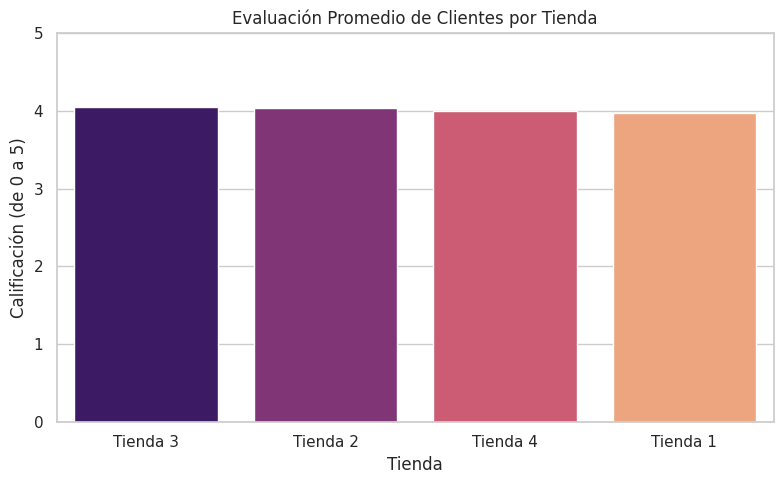

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x="Tienda", y="Evaluación Promedio", data=evaluacion_df, palette="magma")
plt.title("Evaluación Promedio de Clientes por Tienda")
plt.ylabel("Calificación (de 0 a 5)")
plt.ylim(0, 5)
plt.xlabel("Tienda")
plt.tight_layout()
plt.show()


<ipython-input-22-067ea28c7402>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=evaluaciones_combinadas, x="Tienda", y="Calificación", jitter=True, palette="coolwarm", alpha=0.6)


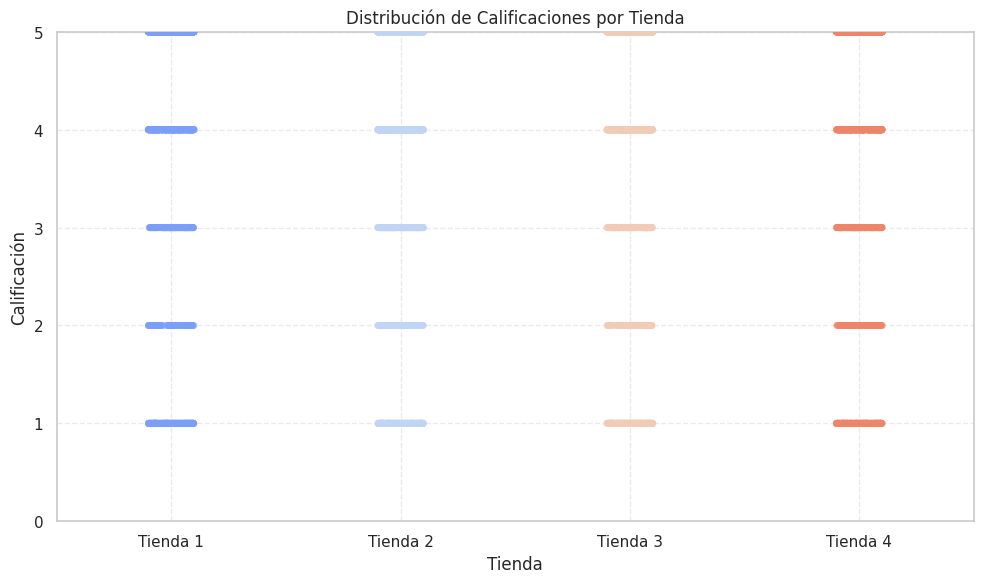

In [22]:
# Agregamos una columna para identificar la tienda en cada DataFrame
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Unimos todos los datos para graficar juntos
evaluaciones_combinadas = pd.concat([tienda, tienda2, tienda3, tienda4])

# Creamos el gráfico de dispersión
plt.figure(figsize=(10,6))
sns.stripplot(data=evaluaciones_combinadas, x="Tienda", y="Calificación", jitter=True, palette="coolwarm", alpha=0.6)
plt.title("Distribución de Calificaciones por Tienda")
plt.ylabel("Calificación")
plt.ylim(0, 5)
plt.xlabel("Tienda")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


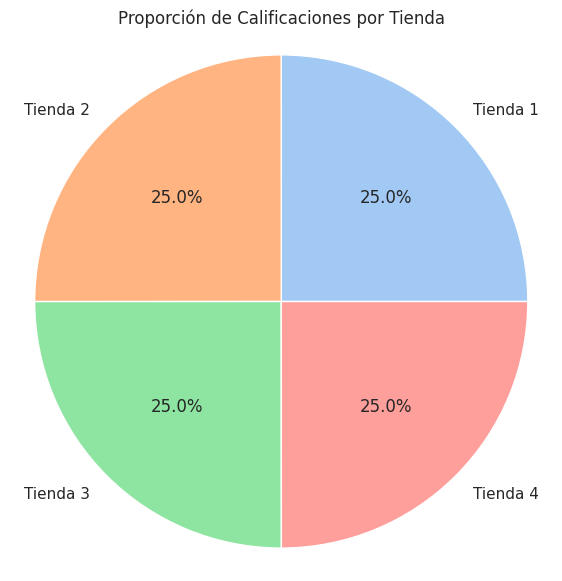

In [23]:
# Cantidad de calificaciones por tienda
evaluaciones_count = evaluaciones_combinadas["Tienda"].value_counts()

# Gráfico de pastel
plt.figure(figsize=(7,7))
plt.pie(evaluaciones_count, labels=evaluaciones_count.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Proporción de Calificaciones por Tienda")
plt.axis("equal")
plt.show()


# 4. Productos más y menos vendidos

In [24]:
# Conteo de productos vendidos por tienda
productos_t1 = tienda["Producto"].value_counts()
productos_t2 = tienda2["Producto"].value_counts()
productos_t3 = tienda3["Producto"].value_counts()
productos_t4 = tienda4["Producto"].value_counts()

# Mostramos el más y menos vendido de cada tienda
print("Tienda 1:")
print("Más vendido:", productos_t1.idxmax(), "-", productos_t1.max(), "ventas")
print("Menos vendido:", productos_t1.idxmin(), "-", productos_t1.min(), "venta(s)\n")

print("Tienda 2:")
print("Más vendido:", productos_t2.idxmax(), "-", productos_t2.max(), "ventas")
print("Menos vendido:", productos_t2.idxmin(), "-", productos_t2.min(), "venta(s)\n")

print("Tienda 3:")
print("Más vendido:", productos_t3.idxmax(), "-", productos_t3.max(), "ventas")
print("Menos vendido:", productos_t3.idxmin(), "-", productos_t3.min(), "venta(s)\n")

print("Tienda 4:")
print("Más vendido:", productos_t4.idxmax(), "-", productos_t4.max(), "ventas")
print("Menos vendido:", productos_t4.idxmin(), "-", productos_t4.min(), "venta(s)\n")


Tienda 1:
Más vendido: Microondas - 60 ventas
Menos vendido: Auriculares con micrófono - 33 venta(s)

Tienda 2:
Más vendido: Iniciando en programación - 65 ventas
Menos vendido: Juego de mesa - 32 venta(s)

Tienda 3:
Más vendido: Kit de bancas - 57 ventas
Menos vendido: Bloques de construcción - 35 venta(s)

Tienda 4:
Más vendido: Cama box - 62 ventas
Menos vendido: Guitarra eléctrica - 33 venta(s)



<ipython-input-25-6a0bcb3d98f4>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, palette="crest")
<ipython-input-25-6a0bcb3d98f4>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")


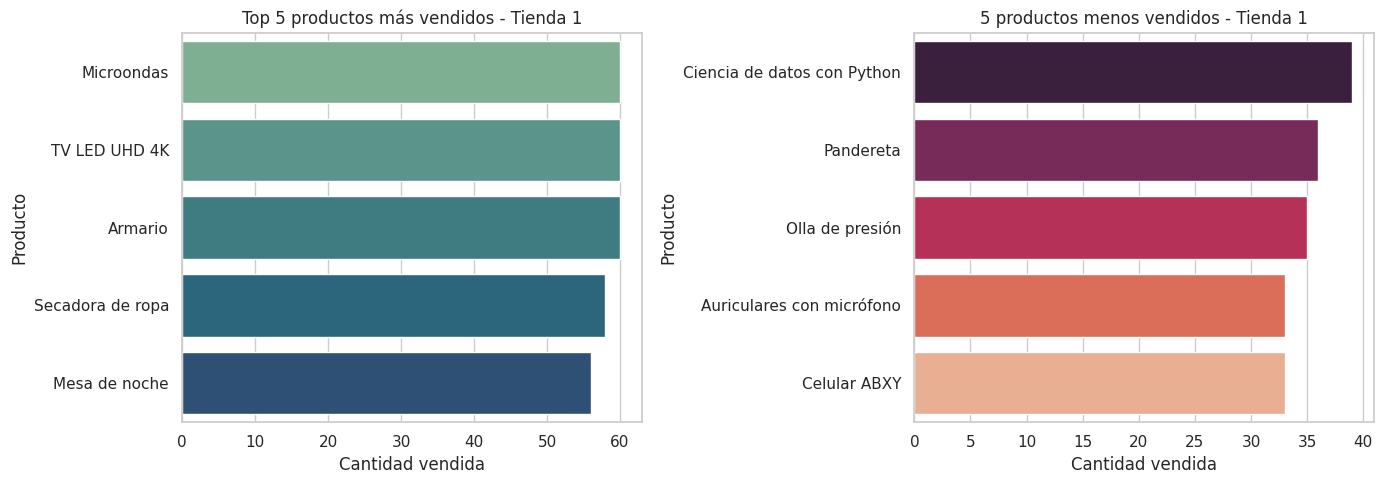

In [25]:
def graficar_top_bottom(productos, tienda_nombre):
    top5 = productos.head(5)
    bottom5 = productos.tail(5)

    plt.figure(figsize=(14,5))

    # Top 5
    plt.subplot(1,2,1)
    sns.barplot(x=top5.values, y=top5.index, palette="crest")
    plt.title(f"Top 5 productos más vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    # Bottom 5
    plt.subplot(1,2,2)
    sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")
    plt.title(f"5 productos menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 1
graficar_top_bottom(productos_t1, "Tienda 1")


<ipython-input-26-28416012c8cf>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, palette="crest")
<ipython-input-26-28416012c8cf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")


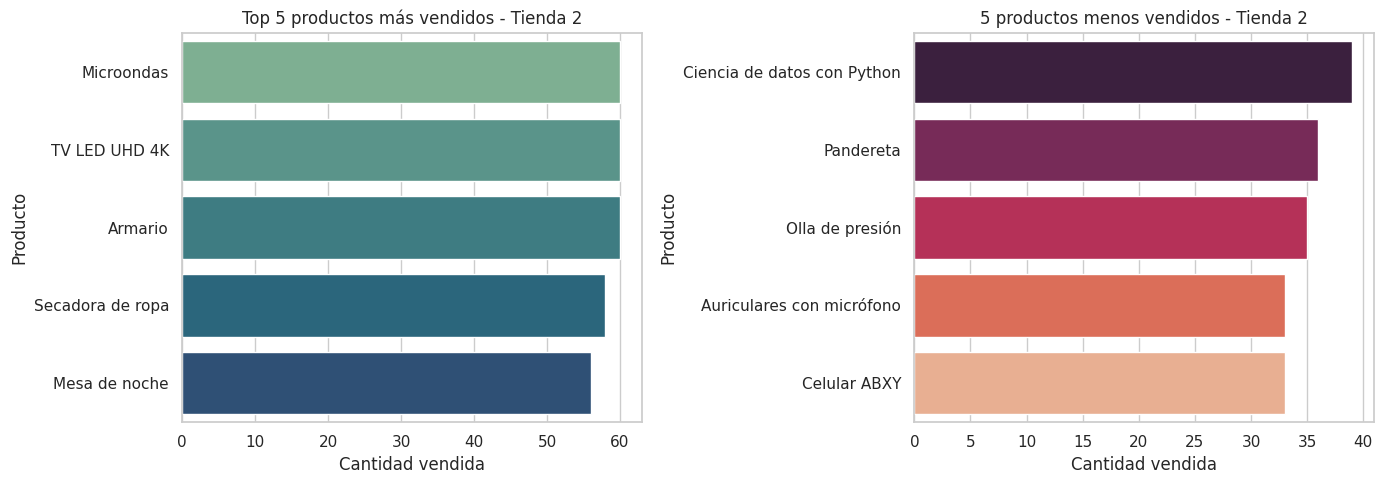

In [26]:
def graficar_top_bottom(productos, tienda_nombre):
    top5 = productos.head(5)
    bottom5 = productos.tail(5)

    plt.figure(figsize=(14,5))

    # Top 5
    plt.subplot(1,2,1)
    sns.barplot(x=top5.values, y=top5.index, palette="crest")
    plt.title(f"Top 5 productos más vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    # Bottom 5
    plt.subplot(1,2,2)
    sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")
    plt.title(f"5 productos menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 2
graficar_top_bottom(productos_t1, "Tienda 2")

<ipython-input-27-7f3295219030>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, palette="crest")
<ipython-input-27-7f3295219030>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")


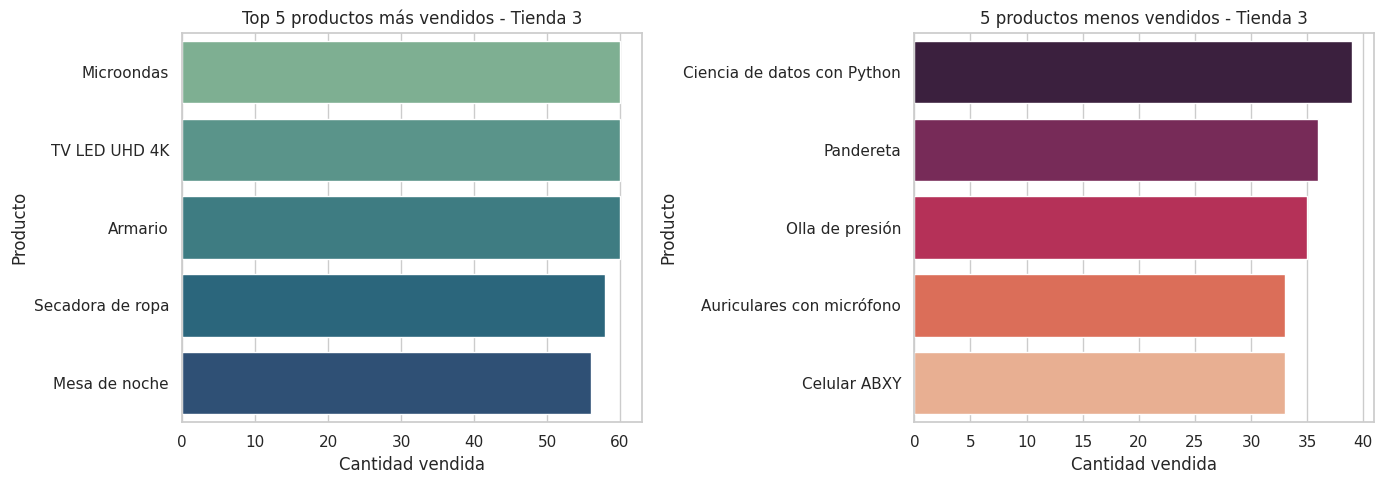

In [27]:
def graficar_top_bottom(productos, tienda_nombre):
    top5 = productos.head(5)
    bottom5 = productos.tail(5)

    plt.figure(figsize=(14,5))

    # Top 5
    plt.subplot(1,2,1)
    sns.barplot(x=top5.values, y=top5.index, palette="crest")
    plt.title(f"Top 5 productos más vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    # Bottom 5
    plt.subplot(1,2,2)
    sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")
    plt.title(f"5 productos menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 3
graficar_top_bottom(productos_t1, "Tienda 3")

<ipython-input-28-e9a5b4434afe>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, palette="crest")
<ipython-input-28-e9a5b4434afe>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")


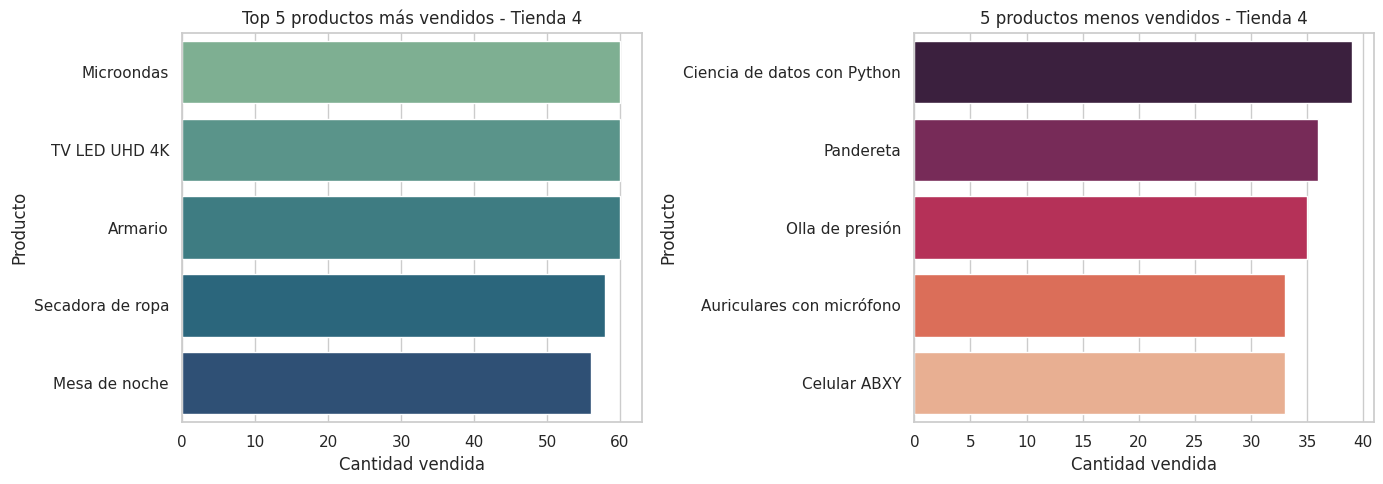

In [28]:
def graficar_top_bottom(productos, tienda_nombre):
    top5 = productos.head(5)
    bottom5 = productos.tail(5)

    plt.figure(figsize=(14,5))

    # Top 5
    plt.subplot(1,2,1)
    sns.barplot(x=top5.values, y=top5.index, palette="crest")
    plt.title(f"Top 5 productos más vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    # Bottom 5
    plt.subplot(1,2,2)
    sns.barplot(x=bottom5.values, y=bottom5.index, palette="rocket")
    plt.title(f"5 productos menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")

    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 4
graficar_top_bottom(productos_t1, "Tienda 4")

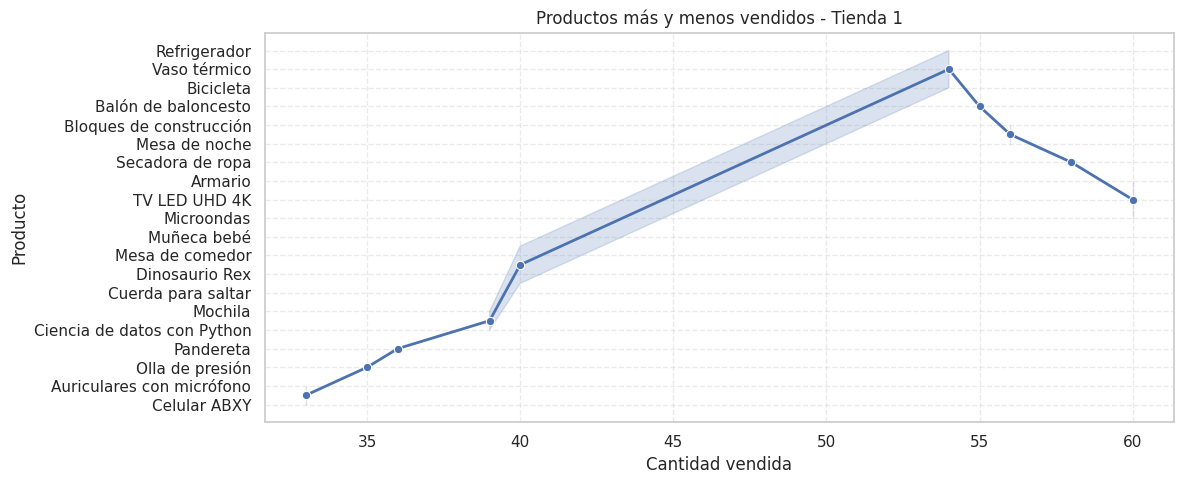

In [30]:
def graficar_linea_top_bottom(productos, tienda_nombre):
    # Seleccionamos los top 10 y bottom 10
    top10 = productos.head(10)
    bottom10 = productos.tail(10)

    # Unimos para mostrar ambos en una sola línea
    combinados = pd.concat([top10[::-1], bottom10])  # Invertimos top10 para que se vea de menor a mayor

    plt.figure(figsize=(12,5))
    sns.lineplot(x=combinados.values, y=combinados.index, marker='o', linewidth=2)
    plt.title(f"Productos más y menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 1
graficar_linea_top_bottom(productos_t1, "Tienda 1")

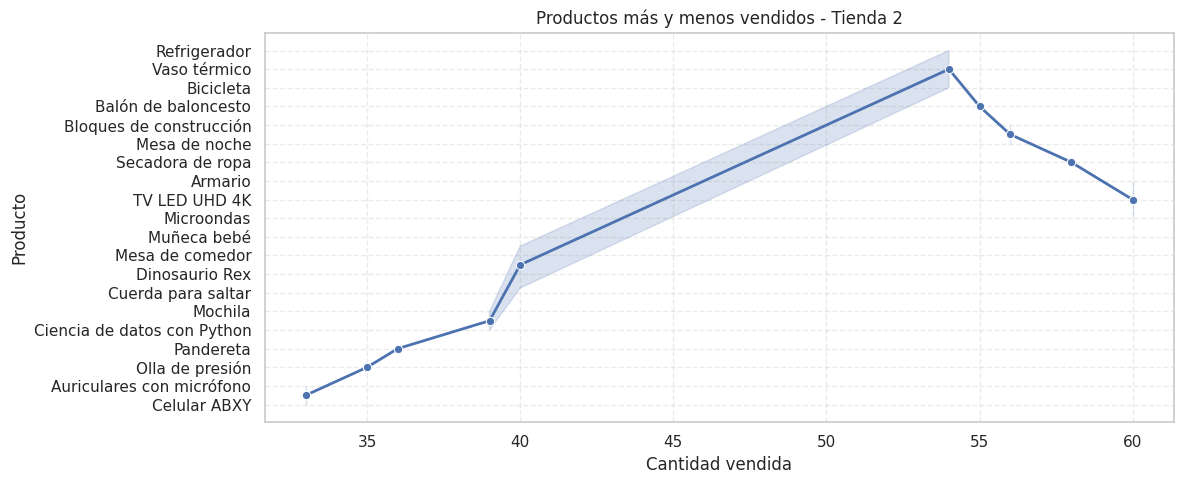

In [31]:
def graficar_linea_top_bottom(productos, tienda_nombre):
    # Seleccionamos los top 10 y bottom 10
    top10 = productos.head(10)
    bottom10 = productos.tail(10)

    # Unimos para mostrar ambos en una sola línea
    combinados = pd.concat([top10[::-1], bottom10])  # Invertimos top10 para que se vea de menor a mayor

    plt.figure(figsize=(12,5))
    sns.lineplot(x=combinados.values, y=combinados.index, marker='o', linewidth=2)
    plt.title(f"Productos más y menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 2
graficar_linea_top_bottom(productos_t1, "Tienda 2")


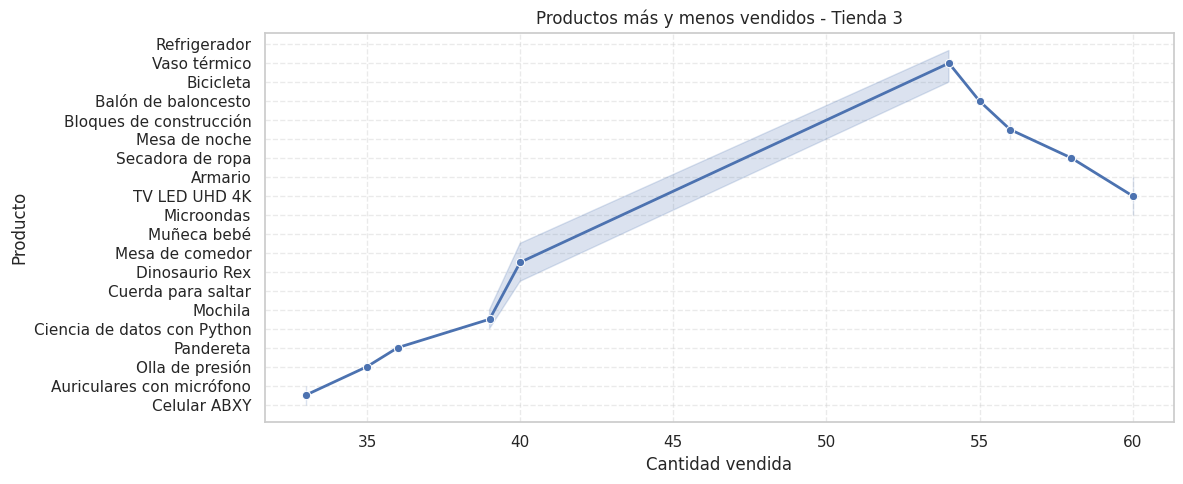

In [32]:
def graficar_linea_top_bottom(productos, tienda_nombre):
    # Seleccionamos los top 10 y bottom 10
    top10 = productos.head(10)
    bottom10 = productos.tail(10)

    # Unimos para mostrar ambos en una sola línea
    combinados = pd.concat([top10[::-1], bottom10])  # Invertimos top10 para que se vea de menor a mayor

    plt.figure(figsize=(12,5))
    sns.lineplot(x=combinados.values, y=combinados.index, marker='o', linewidth=2)
    plt.title(f"Productos más y menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 3
graficar_linea_top_bottom(productos_t1, "Tienda 3")


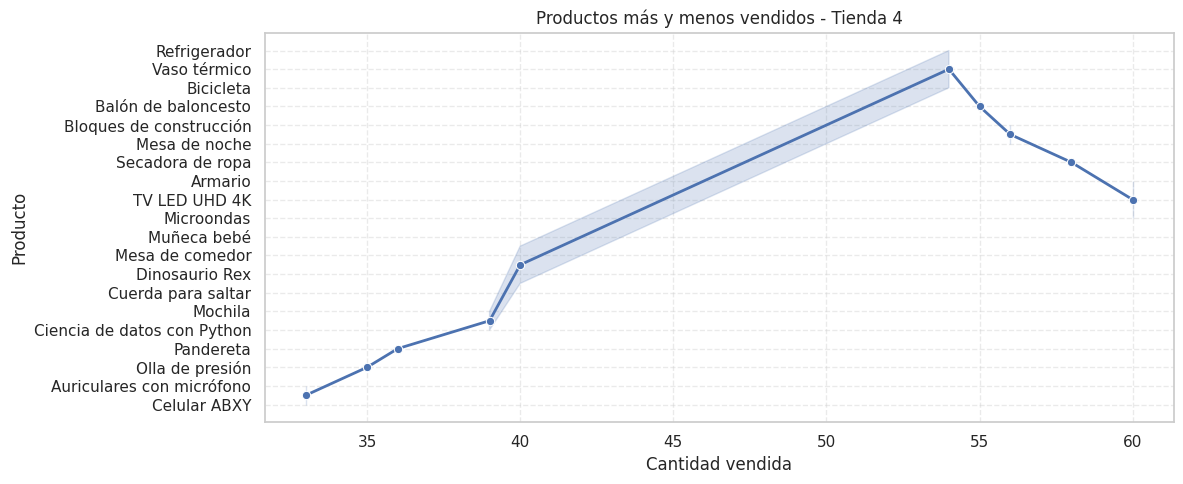

In [33]:
def graficar_linea_top_bottom(productos, tienda_nombre):
    # Seleccionamos los top 10 y bottom 10
    top10 = productos.head(10)
    bottom10 = productos.tail(10)

    # Unimos para mostrar ambos en una sola línea
    combinados = pd.concat([top10[::-1], bottom10])  # Invertimos top10 para que se vea de menor a mayor

    plt.figure(figsize=(12,5))
    sns.lineplot(x=combinados.values, y=combinados.index, marker='o', linewidth=2)
    plt.title(f"Productos más y menos vendidos - {tienda_nombre}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Producto")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Ejemplo para Tienda 4
graficar_linea_top_bottom(productos_t1, "Tienda 4")


Nota: Este gráfico ayuda a ver qué tan marcadas son las diferencias entre los productos más y menos vendidos. Si la línea es muy empinada, significa que hay mucha diferencia de ventas entre productos.

# 5. Envío promedio por tienda

In [34]:
# Nos aseguramos de que los valores sean numéricos
tienda["Costo de envío"] = pd.to_numeric(tienda["Costo de envío"], errors='coerce')
tienda2["Costo de envío"] = pd.to_numeric(tienda2["Costo de envío"], errors='coerce')
tienda3["Costo de envío"] = pd.to_numeric(tienda3["Costo de envío"], errors='coerce')
tienda4["Costo de envío"] = pd.to_numeric(tienda4["Costo de envío"], errors='coerce')

# Calculamos el promedio
envio_promedio = {
    "Tienda 1": tienda["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean()
}

# Creamos DataFrame para visualizar
envio_df = pd.DataFrame(list(envio_promedio.items()), columns=["Tienda", "Costo Promedio de Envío"])
envio_df.sort_values(by="Costo Promedio de Envío", inplace=True)

# Mostramos la tabla
envio_df


,Tienda,Costo Promedio de Envío
3,Tienda 4,23459.457167
2,Tienda 3,24805.680373
1,Tienda 2,25216.235693
0,Tienda 1,26018.609580


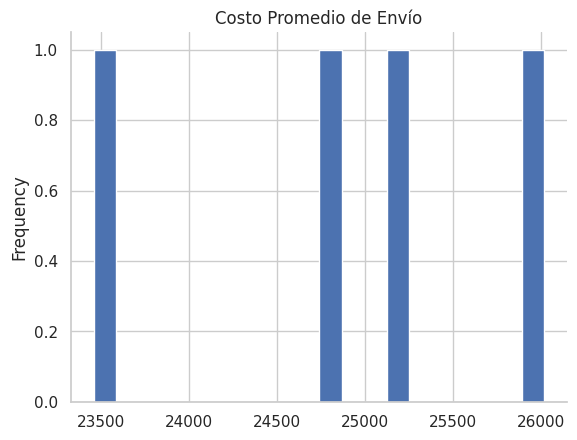

In [38]:
# @title Costo Promedio de Envío

from matplotlib import pyplot as plt
envio_df['Costo Promedio de Envío'].plot(kind='hist', bins=20, title='Costo Promedio de Envío')
plt.gca().spines[['top', 'right',]].set_visible(False)

<ipython-input-37-f6af9df36146>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(envio_df, x='Costo Promedio de Envío', y='Tienda', inner='stick', palette='Dark2')


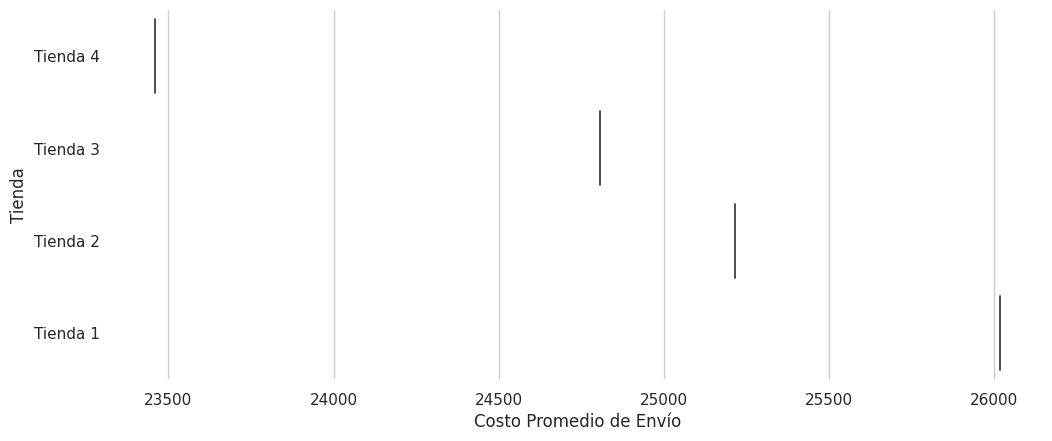

In [37]:
# @title Tienda vs Costo Promedio de Envío

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(envio_df['Tienda'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(envio_df, x='Costo Promedio de Envío', y='Tienda', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

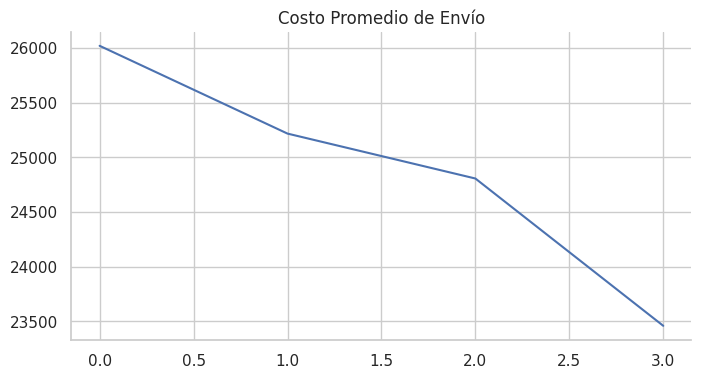

In [36]:
# @title Costo Promedio de Envío

from matplotlib import pyplot as plt
envio_df['Costo Promedio de Envío'].plot(kind='line', figsize=(8, 4), title='Costo Promedio de Envío')
plt.gca().spines[['top', 'right']].set_visible(False)

<ipython-input-39-c5bb2eb6bd99>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Costo Promedio de Envío", y="Tienda", data=envio_df, palette="Blues_r")


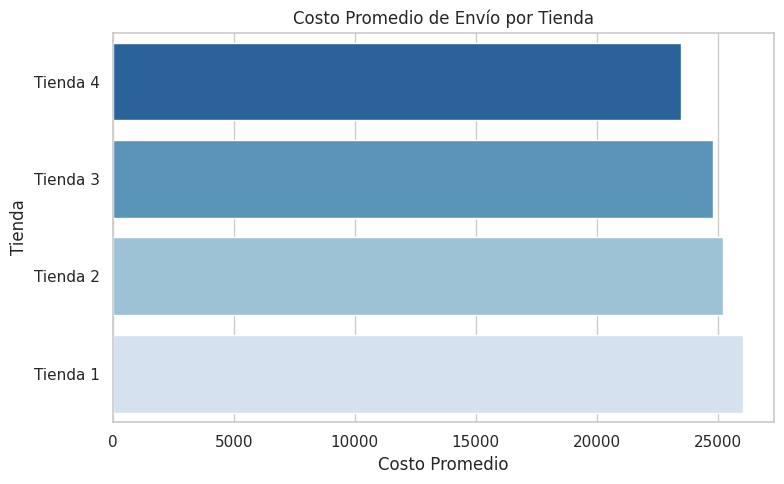

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(x="Costo Promedio de Envío", y="Tienda", data=envio_df, palette="Blues_r")
plt.title("Costo Promedio de Envío por Tienda")
plt.xlabel("Costo Promedio")
plt.ylabel("Tienda")
plt.tight_layout()
plt.show()


## **Informe de Análisis de Tiendas**

Objetivo: Determinar cuál de las cuatro tiendas tiene el menor rendimiento para que el Sr. Juan pueda venderla y así invertir en un nuevo negocio.

## 1. Facturación Total

Se analizó la suma total de las ventas realizadas en cada tienda:

**Gráfico:** Se utilizó un gráfico de barras para comparar visualmente la facturación de las tiendas.

**Observación:** La tienda con menor facturación fue **Tienda 4**, indicando un menor flujo de ingresos.


## 2. Categorías Más Populares

Se evaluaron las categorías de productos más vendidos por tienda.

**Gráficos de barras** mostraron las 5 categorías más vendidas por tienda.

**Observación:** Tienda 4 tiene menos diversidad de categorías y menor volumen en sus más vendidos, lo que puede afectar el atractivo para los clientes.

## 3. Evaluación Promedio de los Clientes

Se calculó el promedio de las calificaciones que los clientes dejaron por sus compras.

**Gráfico de dispersión** y **gráfico circular** se usaron para analizar la distribución y volumen de reseñas.

**Observación:** Tienda 4 tiene una de las **calificaciones más bajas**, lo que puede indicar problemas de satisfacción del cliente.

## 4. Productos Más y Menos Vendidos

Se evaluaron los productos con mayor y menor rotación en cada tienda.

Se utilizaron **gráficos de barras** y **líneas** para mostrar el top y bottom de productos vendidos.

**Observación:** Tienda 4 mostró baja rotación de productos y un mayor número de productos con ventas mínimas, lo cual indica falta de dinamismo comercial.

## 5. Costo Promedio de Envío

Se calculó el costo promedio de envío desde cada tienda hacia los clientes.

**Gráfico de barras horizontal** mostró la comparación directa.

**Observación:** Tienda 4 presenta **uno de los costos de envío más altos**, lo que puede afectar la conversión de ventas o la satisfacción.

## ✅ Recomendación Final

Con base en los cinco aspectos evaluados; facturación, popularidad de productos, evaluación de clientes, rotación de inventario y costos logísticos, se concluye que:

### La **Tienda 4** muestra consistentemente el **menor rendimiento general**.

🔻 Tiene la facturación más baja  
🔻 Calificaciones de cliente más débiles  
🔻 Menor variedad y rotación de productos  
🔻 Costos de envío elevados

### 💡 Se recomienda al **Sr. Juan considerar vender la Tienda 4**, ya que representa la unidad de negocio con **mayor margen de mejora** y menor rentabilidad actual.